# Imports and File Path Setup

In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
import math 

import dask.array as da 
from tifffile import imwrite


In [2]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src'

# Change this variable to the directory where all your data is. Don't remove the r
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny'
#base_dir = r'C:\Users\Kenny\akamatsu'
# Change this variable to the current data you are analyzing in your base_dir.
input_file_directory = 'lumenoid_2_analysis/'

In [60]:
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort, intensity_time_plot_onetrack
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
filtered_tracks_treatment = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

## AP2 Histogram Lifetimes

In [4]:
###### Set the following variables #######


# Background intensity for each channel

# background_channel_1 = 240
# background_channel_2 = 150
# background_channel_3 = 170

# # framerate (in milliseconds)

# framerate_msec = 2200

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [5]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [6]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [7]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [8]:
def trackFilter(region_to_plot, plot_all_channels, tracks, channels_to_plot = [True, True]):
    """
    Filter out tracks based on the specifcations of the

    Parameters:
    1. region_to_plot (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    2. plot_all_channels (bool): If True, all channels are considered. If False, only postive tracks are considered.
    3. tracks (pd.Dataframe): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    4. channels_to_plot (list): List of booleans indicating which channels to plot. Default is [True, True] for both channels.

    Outputs:
    1. pd.DataFrame: Filtered DataFrame containing tracks with the specified region and channel conditions.
    """
        

    if region_to_plot == 'All':
        #filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()

    else:
        # filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()
        # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
        filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

    #channels_to_plot = [True, True]
    if plot_all_channels:
    # tracks_channel_subset_control = filtered_tracks_all_control.copy()
        tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
        return tracks_channel_subset_treatment
    else:
        tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) & (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
        return tracks_channel_subset_treatment

In [10]:
# Plot histogram of all track lengths (lifetimes)
def createHistogramAP2Lifetimes(tracks,framerate_msec, plot_all_channels, bins = np.linspace(0, 300, 51)):
    # Create a histogram of AP2 lifetimes based on the provided tracks DataFrame.
    """
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    2. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    3. plot_all_channels (bool): If True, all channels are considered. If False, tracks with all positive channels are considered.
    4. bins (np.ndarray): Array of bin edges for the histogram. Default is np.linspace(0, 300, 51).

    Outputs:
    1. A histogram plot showing the distribution of AP2 lifetimes in seconds.

    """
    if plot_all_channels:
        # For using the tracks_channel_subset 
        #n, bins, patches = plt.hist(all_lifetimes, bins=50, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        # For using the raw membrane region filtered tracks
        n, bins, patches = plt.hist(tracks['track_length']*framerate_msec/1000, bins=bins, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        n = n.astype('int')

        # Good old loop. Choose colormap of your taste
        for i in range(len(patches)):
            patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

        #plt.hist(all_lifetimes, bins=50, edgecolor=black)
        plt.xlabel('Time (s)')  # X-axis label
        plt.ylabel('Frequency')  # Y-axis label
        plt.title('Track lengths (lifetimes)')  # Title of the histogram
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
        plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
        plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
        plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
        plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
        plt.legend(prop = {'weight':'bold'})
        plt.show()

## Box and Whisker plots of AP2 lifetimes in Membrane Regions

In [44]:
def createBoxWhiskerPlot(tracks, seperate_regions, framerate_msec):
    """
    Create a box-and-whisker plot(s) of AP2 lifetimes based on the provided tracks DataFrame.

    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region' and 'track_length'.
    2. seperate_regions (bool): If True, plots lifetimes for each membrane region separately. If False, pools all data into one boxplot.
    3. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    
    Outputs:
    1. A box-and-whisker plot of AP2 lifetimes, either for each membrane region separately or pooled together.
    
    
    """
    if seperate_regions:
        all_lifetimes = tracks['track_length']*framerate_msec/1000
        plt.boxplot(all_lifetimes, labels=['Lumenoid 2'])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.title('Boxplot of AP2 lifetimes in Lumenoid', fontsize = 14, weight = 'bold')
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']

        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        data = [all_lifetimes_apical, all_lifetimes_lateral, all_lifetimes_basal]
        fig, ax = plt.subplots()
        box = ax.boxplot(data, labels=[label1, label2, label3])
        title = 'AP2 lifetimes in Membrane Regions'
        ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
        ax.set_title(title, fontsize=14, weight='bold')
        for i, line in enumerate(box['medians']):
            x, y = line.get_xdata()[1], line.get_ydata()[0]
            print("x:", line.get_xdata())
            print("y:",line.get_ydata())
            ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')
            plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')
        plt.show()

In [45]:
def compareLumenoidsBoxPlot(lumenoid1, lumenoid2, region_to_plot, lumenoid1_name, lumenoid2_name, lumenoid1_frame_ms, lumenoid2_frame_ms):
    """
    Used to compare the lifetimes of two lumenoids in a box-and-whisker plot

    Parameters:
    1. lumenoid1 (pd.Dataframe): Name of the first lumenoid to filter tracks.
    2. lumenoid2 (pd.Dataframe): Name of the second lumenoid to filter tracks.
    3. region_to_plot (str): The region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    4. lumenoid1_name (str): Name of the first lumenoid for labeling.
    5. lumenoid2_name (str): Name of the second lumenoid for labeling.
    6. lumenoid1_frame_ms (int): Frame rate in milliseconds for the first lumenoid.
    7. lumenoid2_frame_ms (int): Frame rate in milliseconds for the second lumenoid.

    Outputs:
    1. A box-and-whisker plot comparing the lifetimes of the two lumenoids in the specified region.

    """

    if region_to_plot == 'All':
        lumenoid1_lifetimes = lumenoid1['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2['track_length']*lumenoid2_frame_ms/1000
        
        # lumenoid1_all_lifetimes = lumenoid1_all_lifetimes[lumenoid1_all_lifetimes <= 300]
        # lumenoid2_all_lifetimes = lumenoid2_all_lifetimes[lumenoid2_all_lifetimes <= 300]
        title = 'AP2 lifetimes in All Regions'
    else:
        lumenoid1_region_tracks = lumenoid1[lumenoid1['membrane_region'] == region_to_plot]
        lumenoid2_region_tracks = lumenoid2[lumenoid2['membrane_region'] == region_to_plot]

        lumenoid1_lifetimes = lumenoid1_region_tracks['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2_region_tracks['track_length']*lumenoid2_frame_ms/1000

        # lumenoid1_region_lifetimes = lumenoid1_region_lifetimes[lumenoid1_region_lifetimes <= 300]
        # lumenoid2_region_lifetimes = lumenoid2_region_lifetimes[lumenoid2_region_lifetimes <= 300]
        title = f'AP2 lifetimes in {region_to_plot}'
    data = [lumenoid1_lifetimes, lumenoid2_lifetimes]
    fig, ax = plt.subplots()
    box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])

    ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    ax.set_title(title, fontsize=14, weight='bold')
    for i, line in enumerate(box['medians']):
        x, y = line.get_xdata()[1], line.get_ydata()[0]
        print("x:", line.get_xdata())
        print("y:",line.get_ydata())
        ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')

    name1 = f"{lumenoid1_name} (n={len(lumenoid1_region_tracks) if region_to_plot != 'All' else len(lumenoid1)})"
    name2 = f"{lumenoid2_name} (n={len(lumenoid2_region_tracks) if region_to_plot != 'All' else len(lumenoid2)})"
    plt.legend([name1, name2])
    plt.show()

## CDF Plot

In [43]:
# Cumulative plot of track lifetimes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_cumulative_lifetime(tracks, framerate, label_list, title = None):
    """
    Plots a cumulative frequency plot of AP2 lifetimes in different membrane regions.
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, must have 'membrane_region' and 'track_length' columns.
    2. framerate (int): Framerate in milliseconds to convert track lengths to seconds.
    3. label_list (list): List of labels for the different membrane regions to be plotted.
    4. title (str): Title of the plot.
    
    Outputs:
    1. A plot showing the cumulative frequency of AP2 lifetimes in different membrane regions.
    """
    plt.figure(figsize=(8, 7))
    alpha_values = {'orange': 0.5, 'blue': 0.35}
    tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
    tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
    tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
    all_lifetimes_apical = tracks_apical['track_length']*framerate/1000
    all_lifetimes_lateral = tracks_lateral['track_length']*framerate/1000
    all_lifetimes_basal = tracks_basal['track_length']*framerate/1000

    all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
    all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
    all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)
    # Define colors for conditions
    conditions = {label_list[0]: (all_lifetimes_apical_df, 'orange'), label_list[1]: (all_lifetimes_lateral_df, 'blue'), label_list[2]: (all_lifetimes_basal_df,'green')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        alpha = alpha_values.get(color, 1.0)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')

    legend_handles = []
    for label, (df, color) in conditions.items():
        alpha = alpha_values.get(color, 1.0)
        patch = mpatches.Patch(color=color,alpha = alpha, label=label)
        legend_handles.append(patch)
    plt.legend(handles = legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})
    plt.title('Cumulative AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    # Show plot
    # plt.show()
    return plt

## Statistics Functions

In [33]:

def calculate_region_stats(track_data, frame_ms, channels_to_compare="channel1", region ='All'):
    """

    Parameters:
    1. track_data (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'
    2. channels_to_compare (str): String indicating which channels to compare. Default is "channel1" and other options are "channel2" or "both".
    3. region (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    """
    channels_to_plot = [True,True]
    positive_text = "Arp2/3+ Dynamin+"
    if region != "All":
         subset = track_data[track_data['membrane_region'] == region].copy()
    else:
        subset = track_data.copy()


    if channels_to_compare == "channel1":
        negative_text = "Arp2/3- Dynamin+"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    elif channels_to_compare == "channel2":
        negative_text = "Arp2/3+ Dynamin-" 
        total_opposite_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    elif channels_to_compare == "both":
        negative_text = "Arp2/3- Dynamin-"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    else:
        raise ValueError("Invalid channels_to_compare value. Use 'channel1', 'channel2', or 'both'")
    

    

    total_tracks = len(subset)
    total_positive_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    positive_lifetimes = total_positive_tracks['track_length']*(frame_ms/1000)
    negative_lifetimes = total_opposite_tracks['track_length']*(frame_ms/1000)
    total_positive_tracks = len(total_positive_tracks)
    total_negative_tracks = len(total_opposite_tracks)
    print(f"Total tracks in {region}: {total_tracks}")
    print(f"Total {positive_text} in {region}: {total_positive_tracks}")
    print(f"Total {negative_text} in {region}: {total_negative_tracks}")
    print(f"Percentage of {positive_text} tracks in {region}: {total_positive_tracks / total_tracks * 100:.2f}%")
    print(f"Percentage of {negative_text} in {region}: {total_negative_tracks / total_tracks * 100:.2f}%")
    #print(f'Median lifetime of {positive_text} in {region}: {np.median(positive_lifetimes):.2f} s')
    #print(f'Median lifetime of {negative_text} in {region}: {np.median(negative_lifetimes):.2f} s')
    print(f'Mean lifetime of {positive_text} in {region}: {np.mean(positive_lifetimes):.2f} s')
    print(f'Mean lifetime of {negative_text} in {region}: {np.mean(negative_lifetimes):.2f} s')
calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Basal')

Total tracks in Basal: 2011
Total Arp2/3+ Dynamin+ in Basal: 655
Total Arp2/3- Dynamin+ in Basal: 630
Percentage of Arp2/3+ Dynamin+ tracks in Basal: 32.57%
Percentage of Arp2/3- Dynamin+ in Basal: 31.33%
Mean lifetime of Arp2/3+ Dynamin+ in Basal: 55.79 s
Mean lifetime of Arp2/3- Dynamin+ in Basal: 34.99 s


## Intensity Graphs

In [15]:
def intensity_region_plot(track,toNormalize = True,toFrequencyDensity = True,channel_to_plot = "channel1"):
    """
    """
    if channel_to_plot == "channel1":
        columns = ['C1_adjusted_voxel_sum']
        title_channel = 'Arp2/3'
    elif channel_to_plot == "channel2":
        columns = ['C2_adjusted_voxel_sum']
        title_channel = 'Dynamin2'
    #marker = ['ArpC3']
    tracks_apical = track[track['membrane_region'] == 'Apical']
    tracks_lateral = track[track['membrane_region'] == 'Lateral']
    tracks_basal = track[track['membrane_region'] == 'Basal']

    apical_AP2 = tracks_apical['C3_adjusted_voxel_sum'].reset_index(drop=True)
    lateral_AP2 = tracks_lateral['C3_adjusted_voxel_sum'].reset_index(drop=True)
    basal_AP2 = tracks_basal['C3_adjusted_voxel_sum'].reset_index(drop=True)

    max_apical_AP2 = []
    for j in range(len(apical_AP2)):
        max_apical_AP2.append(max(apical_AP2[j]))  
    max_lateral_AP2 = []
    for j in range(len(lateral_AP2)):
        max_lateral_AP2.append(max(lateral_AP2[j])) 
    max_basal_AP2 = []
    for j in range(len(basal_AP2)):
        max_basal_AP2.append(max(basal_AP2[j])) 

    for i in range(len(columns)):
        # Create a figure with 2 subplots side by side
        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig1, ax1 = plt.subplots(figsize=(6, 5.25))
        fig2, ax2 = plt.subplots(figsize=(6, 5.25))

        apical =  tracks_apical[columns[i]].reset_index(drop=True)
        lateral =  tracks_lateral[columns[i]].reset_index(drop=True)
        basal =  tracks_basal[columns[i]].reset_index(drop=True)
        max_apical = []
        for j in range(len(apical)):
            max_apical.append(max(apical[j]))  
        max_lateral = []
        for j in range(len(lateral)):
            max_lateral.append(max(lateral[j])) 
        max_basal = []
        for j in range(len(basal)):
            max_basal.append(max(basal[j]))  

        # Normalize to max AP2 intensity, optional
        if toNormalize:
            max_apical = (np.array(max_apical) / np.array(max_apical_AP2)).tolist()
            max_lateral = (np.array(max_lateral) / np.array(max_lateral_AP2)).tolist()
            max_basal = (np.array(max_basal) / np.array(max_basal_AP2)).tolist()

        bins = np.linspace(min(min(max_apical), min(max_lateral),min(max_basal)), max(max(max_apical), max(max_lateral),max(max_basal)), 50)
        # Plot histogram on the first subplot
        if toFrequencyDensity:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7,density=True, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5,density=True, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35,density=True, label=label3)
            ax1.set_ylabel('Frequency Density', fontsize=12, weight='bold')
        else:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35, label=label3)
            ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
        ax1.set_xlabel('Normalized Intensity (A.U.)', fontsize=12, weight='bold')
        ax1.legend(prop={'weight': 'bold'}, loc ='upper right')
        boxplot_data = [max_apical, max_lateral, max_basal]
        bp = ax2.boxplot(boxplot_data, patch_artist=True)
        median_line = bp['medians'][0]
        median_y = median_line.get_ydata()[0]  # Y-value of the median
        ax2.hlines(y=median_y, xmin=1, xmax=2, color='grey', linewidth=0.5, linestyle='--')

        # Loop through each median line and place value beside it
        for j, median in enumerate(bp['medians']):
            xdata = median.get_xdata()
            ydata = median.get_ydata()
            x = xdata.mean()   # horizontal center of median line
            y = ydata[0]       # vertical location of median

            if j == 0:
                # Left box: place text to the left
                ax2.text(x - 0.25, y, f'{y:.2f}', ha='right', va='center', fontsize=10, weight='bold', color='black')
            elif j == 1:
                # middle box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')
            else:
                # Right box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')

        bp['boxes'][0].set(facecolor='orange', alpha=0.7)
        bp['boxes'][1].set(facecolor='blue', alpha=0.5)
        bp['boxes'][2].set(facecolor='green', alpha=0.35)
        for k in range(3):
            bp['medians'][k].set(color='black', linewidth=1.5)
        ax2.set_xticklabels([label1, label2, label3], fontsize=12, weight='bold')
        ax2.set_ylabel(f'Normalized maximum {title_channel} intensity (A.U.)', fontsize=12, weight='bold')
        # Adjust layout
        plt.tight_layout()
        plt.show()

## CCS Growth Distribution

In [41]:
def extract_trackid_data(track, track_id):
    track_data = track[track['track_id'] == track_id].copy(deep = True)
    return track_data

In [42]:

def group_intensities_trackid(track,track_id, time_interval=12):
    track_data = extract_trackid_data(track,track_id)
    
    return track_data['c3_voxel_sum_adjusted'].tolist()


In [75]:
background_channel_3 = 170
def extract_slope(intensities, framerate_msec, time_interval=12, channel_to_plot = "c3"):
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds
    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))

    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        intdiff = np.zeros(lint)
        if lint <= prange:
            slopes.append(intdiff)
        # performing least squares fitting
        curmax = np.max(intensity) - background_channel_3
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            temp = (intensity[sub_indices] - background_channel_3) / curmax
            tempx = sub_indices * (framerate_msec/1000)
            tempy = temp

            n = len(tempx)
            numer = n * np.sum(tempx * tempy) - np.sum(tempx) * np.sum(tempy)
            denom = n * np.sum(tempx ** 2) - (np.sum(tempx)) ** 2
            if denom != 0:
                intdiff[j] = numer / denom
            else:
                intdiff[j] = 0
        slopes.append(intdiff)
    return slopes

## Lumenoid 2 Plots

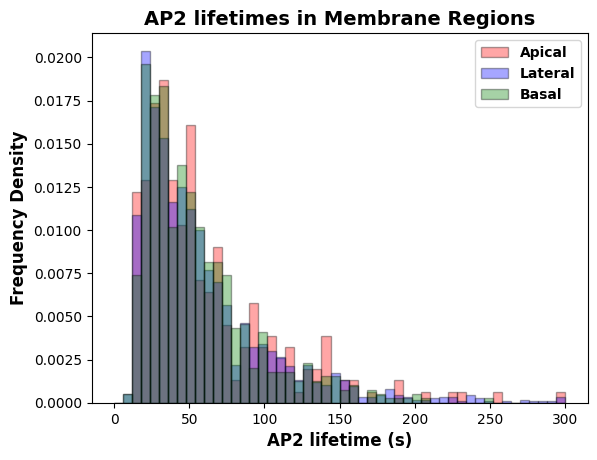

In [46]:
tracks_channel_subset_treatment = trackFilter('All', False, filtered_tracks_treatment)
lumenoid2_frame_ms = 2100
createHistogramAP2Lifetimes(tracks_channel_subset_treatment,lumenoid2_frame_ms,False)

<module 'matplotlib.pyplot' from 'c:\\Users\\Kenny\\anaconda3\\envs\\cme_pipeline\\lib\\site-packages\\matplotlib\\pyplot.py'>

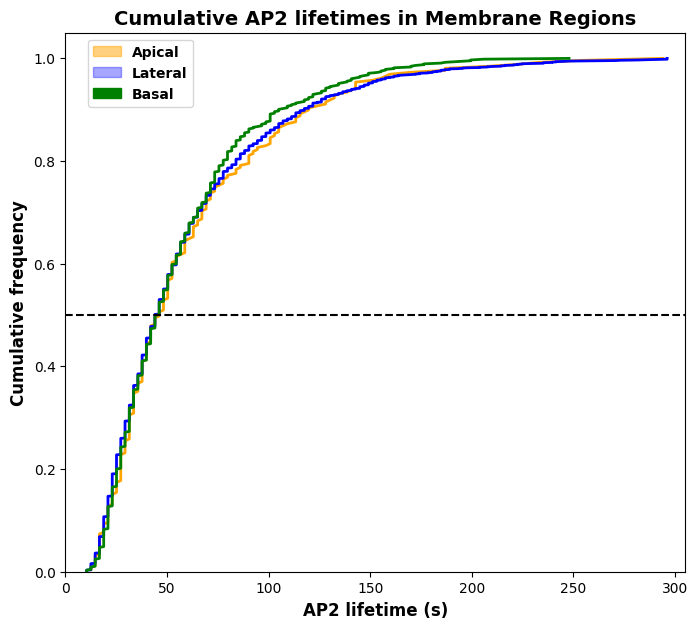

In [47]:
# Cumulative plot of track lifetimes
plot_cumulative_lifetime(tracks_channel_subset_treatment, lumenoid2_frame_ms, [label1, label2, label3])


x: [0.85 1.15]
y: [46.2 46.2]
x: [1.85 2.15]
y: [44.1 44.1]
x: [2.85 3.15]
y: [46.2 46.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_26904\4289633991.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


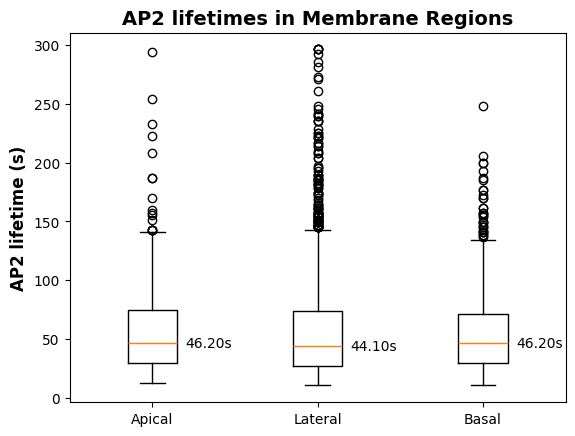

In [48]:
createBoxWhiskerPlot(tracks_channel_subset_treatment,False,lumenoid2_frame_ms)

## Lumenoid 1 Plots

In [49]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
lumenoid1_frame_ms = 2200


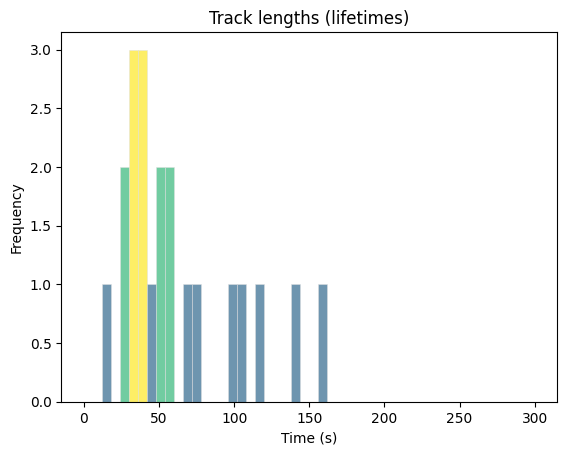

In [50]:
tracks_channel_subset_compare = trackFilter('All', False, compare_lumenoid_df)
createHistogramAP2Lifetimes(tracks_channel_subset_compare,lumenoid1_frame_ms,True)

x: [0.85 1.15]
y: [44. 44.]
x: [1.85 2.15]
y: [24.2 24.2]
x: [2.85 3.15]
y: [24.2 24.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_26904\4289633991.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


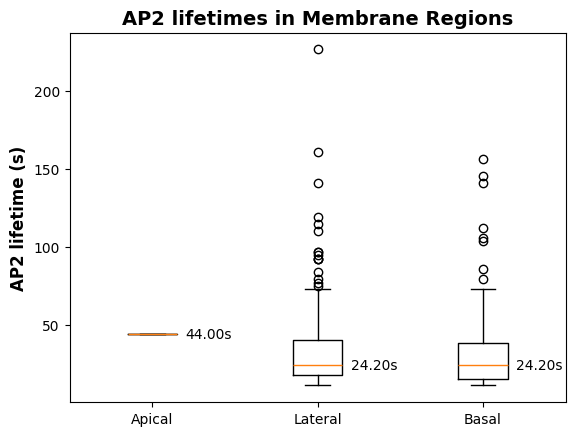

In [51]:
createBoxWhiskerPlot(compare_lumenoid_df,False,lumenoid1_frame_ms)

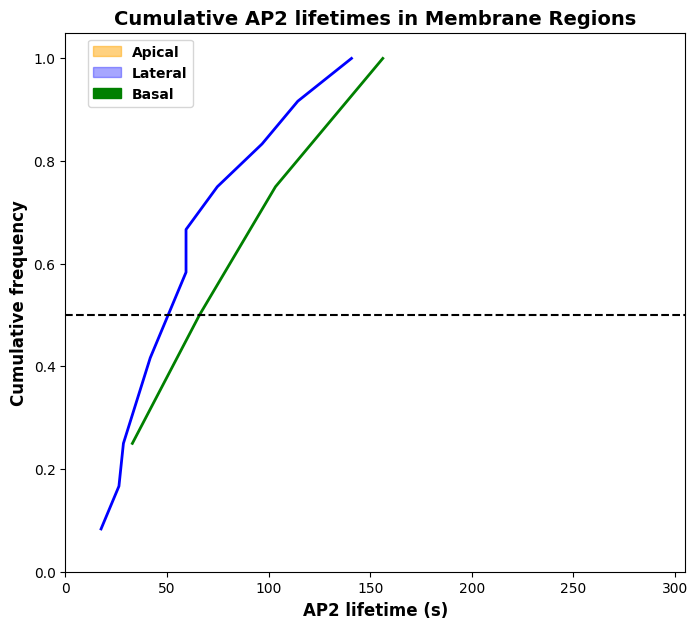

In [52]:

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(tracks_channel_subset_compare, lumenoid1_frame_ms, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

## Lumenoid 1 and Lumenoid 2 Comparasion Plots

x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [29.4 29.4]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_26904\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


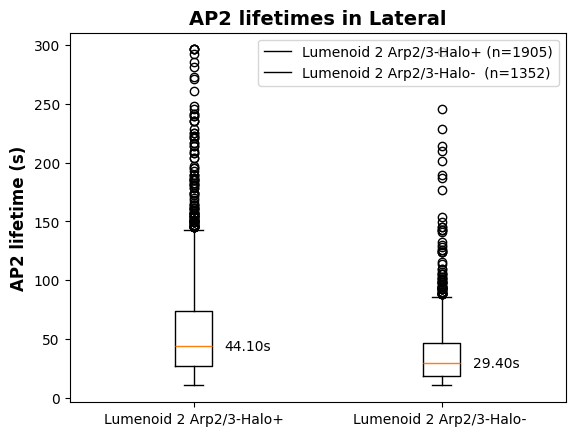

In [53]:
channels_to_plot = [True,True]
arp_negative = [False, True]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment, channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,arp_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'Lateral', 'Lumenoid 2 Arp2/3-Halo+', 'Lumenoid 2 Arp2/3-Halo- ', lumenoid2_frame_ms, lumenoid2_frame_ms)


C:\Users\Kenny\AppData\Local\Temp\ipykernel_26904\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [25.2 25.2]


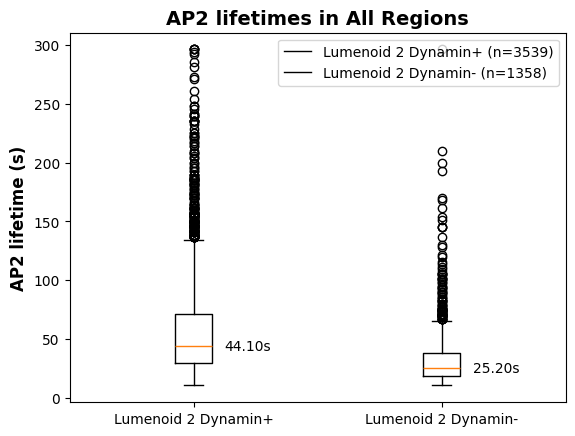

In [54]:
channels_to_plot = [True,True]
arp_negative = [False, True]
dynamin_negative = [True, False]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,dynamin_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'All', 'Lumenoid 2 Dynamin+', 'Lumenoid 2 Dynamin-', lumenoid2_frame_ms, lumenoid2_frame_ms)


In [55]:
calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Apical')

Total tracks in Apical: 880
Total Arp2/3+ Dynamin+ in Apical: 259
Total Arp2/3- Dynamin+ in Apical: 230
Percentage of Arp2/3+ Dynamin+ tracks in Apical: 29.43%
Percentage of Arp2/3- Dynamin+ in Apical: 26.14%
Mean lifetime of Arp2/3+ Dynamin+ in Apical: 60.35 s
Mean lifetime of Arp2/3- Dynamin+ in Apical: 36.43 s


## Intensity Plots

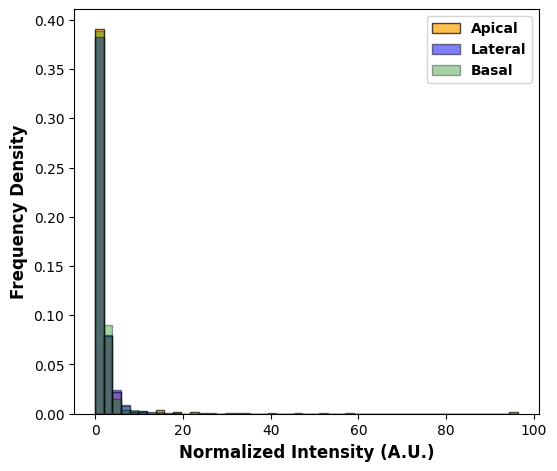

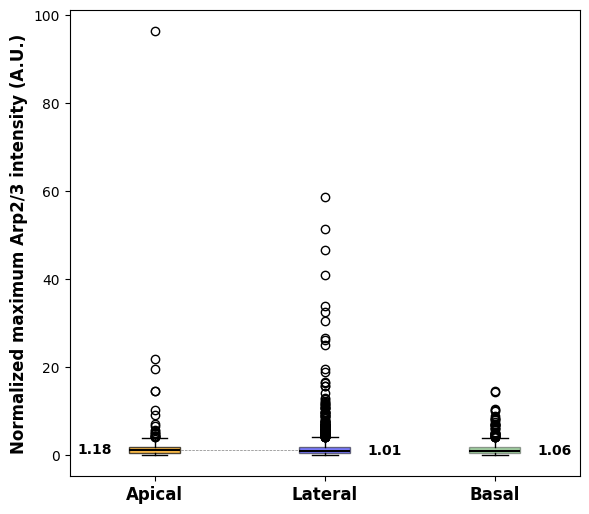

In [56]:
lumenoid_intensity = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
intensity_region_plot(lumenoid_intensity,True,True,'channel1')

## CCS Growth Distribution Lumenoid 2 Testing

In [57]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_track_df = pd.read_pickle(input_directory_all_tracks_full)
ccs_track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c2_vol_bg,c3_peak_mean,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg
0,0,126.0,523.0,34.0,533.0,2213,NaN,3,2,2,...,441,262.274286,556,45898,20724.315789,125,523,32,175,441
1,0,159.0,422.0,37.0,17.0,2212,NaN,3,2,2,...,441,6.511494,22,1133,268.909434,157,422,35,174,439
2,0,98.0,483.0,38.0,372.0,2222,NaN,3,2,2,...,441,168.908571,530,29559,2851.105263,99,485,41,175,441
3,0,90.0,533.0,38.0,36.0,2221,NaN,3,2,2,...,437,4.891566,36,812,288.160377,89,532,37,166,378
4,0,85.0,352.0,37.0,1199.0,2220,NaN,3,2,2,...,441,407.440000,1199,71302,32061.210526,85,351,36,175,441


tracks_to_plot 0


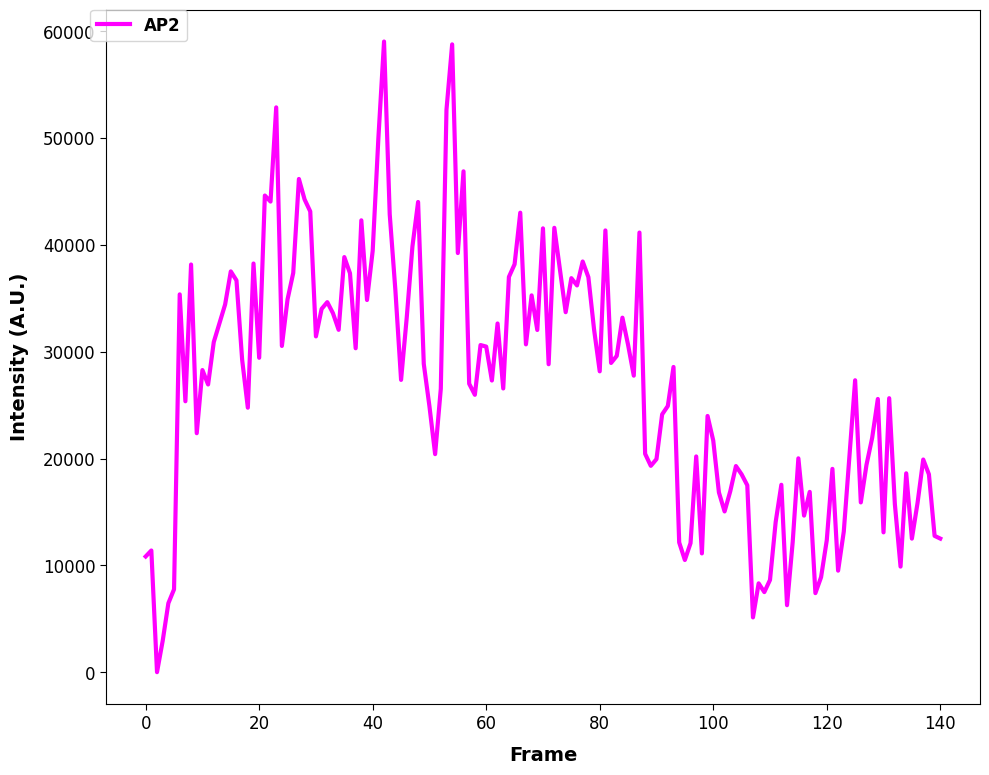

In [61]:
value_to_plot = 'voxel_sum_adjusted'
channel3_name = 'AP2'
channel2_name = 'Dynamin2'
channel1_name = 'ArpC3'

# set 'normalized = False' to plot raw intensities
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(input_directory_all_tracks_full)
intensity_time_plot_onetrack(dataframe = track_df, tracks_to_plot = 0, 
intensity_to_plot = [f'c3_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 1, legend_values = [channel3_name],
line_colors = ['magenta'], graph_title = f'{value_to_plot}', normalized=False, save_plot = False)

In [ ]:
testing = [np.array(group_intensities_trackid(track_df, 0))]
#print(testing)
#testing[0][0]
slopes_testing = extract_slope(testing,lumenoid2_frame_ms,time_interval=10)
print(slopes_testing)
#len(testing)
#track_frames = testing['frame']
#track_frames.head()
#track_ints = testing['c3_voxel_sum_adjusted']

#num_rows = 1
#num_cols = 1
#fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))
#axes.plot(testing['frame'], testing[f'c3_{value_to_plot}'], label="AP2", color='magenta', linewidth = 3)

[array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -5.66824443e-03,
        3.05117144e-02,  4.68894134e-02,  5.41868301e-02,  3.34491452e-02,
        1.59039849e-02, -1.02368469e-02, -1.61065480e-05, -6.77021559e-04,
        1.60934660e-02,  1.46458290e-02,  1.46302260e-02,  1.42502800e-03,
       -1.16269783e-02, -5.51836843e-03, -8.35640166e-03,  1.11861535e-02,
        2.59612014e-02,  3.60182000e-02,  6.48409540e-03, -1.25931733e-03,
       -1.78923770e-02, -6.56391789e-03,  1.30715701e-03,  2.07608116e-02,
       -4.16205445e-04, -1.29344319e-02, -2.08233661e-02, -1.58444216e-02,
       -1.00385978e-02,  6.28402206e-03,  5.78133531e-03, -7.39811184e-04,
        7.65325503e-03,  3.59120791e-03,  1.54212113e-03,  1.72784765e-02,
        3.56125764e-02,  1.78778666e-02,  4.95109451e-03, -2.48174912e-02,
       -3.86882616e-02, -2.77277480e-02,  4.97877458e-03,  4.61715953e-03,
       -4.42644979e-03, -2.58015150e-02, -2.94102874e-02,  6.59814599e-03,
        4.97162883e-02, 